# M6 — Notebook 04 · Feature assembly, the epi-week join & QC

Batches A, B and C are extracted (notebooks 01, 03, 02). They live on three different clocks:
terrain and settlement structure are one row per district, LST is an 8-day composite, NDVI/EVI a
16-day one. The model needs a single **district × epi-week** matrix.

Turning three clocks into one is where a leakage bug gets in, so that join is the subject of this
notebook rather than a step buried inside it.

### The leakage rule this notebook exists to enforce

An 8-day LST composite labelled `composite_start = 2020-06-01` summarises **2020-06-01 through
2020-06-08 inclusive**. Joining it to the epi-week beginning 2020-06-01 would put eight days of
observation — including seven days of the future — inside a predictor for that week.

So: a composite is admissible for week *W* only if it **ended strictly before** *W* began. Then
lag 0–8 weeks back from there, mirroring M2's climate-lag design so the ladder comparison stays
like-for-like. §6 measures what the naive join would have cost; the answer is not small.

The companion rule: **cloud gaps are filled with past data only.** `interpolate()` across a gap
reaches into the future and is banned here. Forward-fill is safe — but it silently manufactures a
value, so every filled cell carries the **age** of the observation it was filled from, and §9
audits that age rather than trusting it.

### What this notebook does *not* do

It does not touch the outcome, the label, or the split. `docs/M6.md` §8 defines the model rows as
the **existing M1/M2/M5 panel spine** — M6 is scored on identical rows or not at all. That panel
is not staged on this machine, so what follows is the **feature side only**, on a candidate spine
covering the full 2018–2025 window. Notebook 05 intersects it with the real panel, and the row set
is the panel's, never this notebook's.

### Steps

1. Assert the chain back to notebooks 00–03
2. Build the epi-week spine and check it against a frozen artifact
3. State and hand-verify the leakage rule on one district, one week
4. Measure what the naive join would have leaked
5. Audit source coverage before joining — the gaps decide how much forward-fill happens
6. Run the as-of lag join, 6 dynamic layers × lags 0–8
7. Audit staleness and flag manufactured cells
8. Broadcast the static block
9. Assemble, then re-test the leakage rule mechanically over every cell
10. QC: missingness, collinearity, and whether temporal signal survived the join

## 1 · Setup, and assert the chain

In [1]:
import json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
QUAR = REPO / "data_quarantine" / "m6_geomatics"
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"

prov0 = json.loads((QUAR / "nb00_provenance.json").read_text())
prov1 = json.loads((QUAR / "nb01_provenance.json").read_text())
prov2 = json.loads((QUAR / "nb02_provenance.json").read_text())
prov3 = json.loads((QUAR / "nb03_provenance.json").read_text())

rdhs = gpd.read_file(GEOM)
sha_now = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]
for name, p in [("00", prov0), ("01", prov1), ("02", prov2), ("03", prov3)]:
    assert p["geometry_sha256_16"] == sha_now, f"notebook {name} ran on a different geometry — stop"

SEED = prov0["seed"]
N_UNITS = len(rdhs)

print("frame verified against notebooks 00-03")
print("  units        :", N_UNITS)
print("  geometry sha :", sha_now)
print("  seed         :", SEED)
print("  batch A      :", prov1["output_sha256_16"])
print("  batch B      :", prov3["output_sha256_16"])
print("  batch C LST  :", prov2["lst"]["sha256_16"], f'({prov2["lst"]["n_composites"]} composites)')
print("  batch C VI   :", prov2["vi"]["sha256_16"], f'({prov2["vi"]["n_composites"]} composites)')

frame verified against notebooks 00-03
  units        : 26
  geometry sha : 9e5e2c0a541ecac1
  seed         : 20260612
  batch A      : 1ef4bc27298b7082
  batch B      : 716844d268e349f9
  batch C LST  : 1c0950fc4f25ca82 (350 composites)
  batch C VI   : 824cd1d1fdffa510 (177 composites)


## 2 · Configuration

The window starts **2018-01-01** to match the outcome dataset (WER, 2018–2025). Notebook 02
deliberately extracted from 2017-11 so that an 8-week lag exists for the very first 2018 week —
this is where that pre-roll gets spent.

`MAX_AGE_DAYS = 30` is the staleness gate. It is not a drop rule (§8 of `M6.md` forbids dropping
panel rows); it flags cells whose value was forward-filled from an observation older than a month,
so a reader can see which district-weeks rest on carried data.

In [2]:
WIN_START, WIN_END = "2018-01-01", "2025-12-31"
LAGS = list(range(0, 9))          # 0-8 weeks, mirroring M2's climate lag design
MAX_AGE_DAYS = 30                 # staleness flag threshold (not a drop rule)

# the six layers that actually move in time (notebook 02 §15)
DYN_COLS = {
    "lst": ["lst_day_mean", "lst_night_mean", "lst_mean", "lst_dtr"],
    "vi":  ["ndvi_mean", "evi_mean"],
}

OUT_CSV = QUAR / "m6_features_weekly_srilanka_v1.csv"

print("window   :", WIN_START, "->", WIN_END)
print("lags     :", LAGS, "weeks")
print("dynamic  :", sum(len(v) for v in DYN_COLS.values()), "layers x", len(LAGS), "lags =",
      sum(len(v) for v in DYN_COLS.values()) * len(LAGS), "columns")
print("stale gate:", MAX_AGE_DAYS, "days")

window   : 2018-01-01 -> 2025-12-31
lags     : [0, 1, 2, 3, 4, 5, 6, 7, 8] weeks
dynamic  : 6 layers x 9 lags = 54 columns
stale gate: 30 days


## 3 · Load the four feature tables

Two static (one row per district), two dynamic (one row per composite × district). Print the
shapes and the clocks before assuming anything about how they line up.

In [3]:
terrain = pd.read_csv(QUAR / "m6_batchA_terrain_srilanka.csv")
statics = pd.read_csv(QUAR / "m6_batchB_statics_srilanka.csv")
lst = pd.read_csv(QUAR / "m6_lst_terra_8day_srilanka.csv",
                  parse_dates=["composite_start", "composite_end"])
vi  = pd.read_csv(QUAR / "m6_vi_terra_16day_srilanka.csv",
                  parse_dates=["composite_start", "composite_end"])

for nm, d in [("batch A terrain", terrain), ("batch B statics", statics),
              ("batch C LST", lst), ("batch C VI", vi)]:
    print(f"{nm:<16} {str(d.shape):<12} units={d.rdhs_id.nunique()}")

assert set(terrain.rdhs_id) == set(statics.rdhs_id) == set(lst.rdhs_id) == set(vi.rdhs_id) == set(rdhs.rdhs_id), \
    "unit keys disagree across batches — stop"
print("\nall four tables carry the same 26 unit keys")

batch A terrain  (26, 23)     units=26
batch B statics  (26, 20)     units=26
batch C LST      (9100, 12)   units=26
batch C VI       (4602, 10)   units=26

all four tables carry the same 26 unit keys


### How long is a composite, really?

The leakage rule depends on `composite_end` meaning *the last day observed*. Check that against
the nominal cadence rather than assuming the column was built the way the docs say.

In [4]:
for nm, d, cadence in [("LST", lst, 8), ("VI", vi, 16)]:
    span = (d.composite_end - d.composite_start).dt.days + 1      # inclusive
    print(f"{nm}: nominal {cadence}-day | observed span days:",
          span.value_counts().sort_index().to_dict())

print("""
The short spans are the MODIS year boundary: the 8/16-day grid restarts every 1 Jan, so the last
composite of a year is truncated. `composite_end` is inclusive of its final day, which is what the
strict inequality in section 5 relies on.""")

LST: nominal 8-day | observed span days: {5: 182, 6: 52, 8: 8866}
VI: nominal 16-day | observed span days: {16: 4602}

The short spans are the MODIS year boundary: the 8/16-day grid restarts every 1 Jan, so the last
composite of a year is truncated. `composite_end` is inclusive of its final day, which is what the
strict inequality in section 5 relies on.


## 4 · The epi-week spine

Weeks are keyed by their **Monday start date**. That is not an assumption — it is checkable
against a frozen artifact of the published pipeline, `ALT_STATS/frozen/srilanka_matched_pairs.csv`,
whose `predictor_week` / `target_week` columns are the analysis's own week keys.

Two things to verify: that those weeks are all Mondays, and that every one of them falls inside the
spine built here. If either fails, this notebook is on a different calendar from the manuscript and
the whole join is wrong.

In [5]:
WEEKS = pd.date_range(WIN_START, WIN_END, freq="W-MON")

mp = pd.read_csv(REPO / "ALT_STATS" / "frozen" / "srilanka_matched_pairs.csv",
                 parse_dates=["predictor_week", "target_week"])
mp_weeks = pd.Index(sorted(set(mp.predictor_week) | set(mp.target_week)))

print("spine        :", len(WEEKS), "weeks |", WEEKS[0].date(), "->", WEEKS[-1].date())
print("frozen artifact:", len(mp_weeks), "distinct weeks |", mp_weeks[0].date(), "->", mp_weeks[-1].date())
print("  all Mondays :", bool((mp_weeks.dayofweek == 0).all()))
print("  all in spine:", bool(mp_weeks.isin(WEEKS).all()))

assert (mp_weeks.dayofweek == 0).all(), "frozen artifact is not Monday-keyed — stop"
assert mp_weeks.isin(WEEKS).all(), "frozen weeks fall outside this spine — calendar mismatch, stop"
print("\nweek convention agrees with the frozen pipeline")

spine        : 418 weeks | 2018-01-01 -> 2025-12-29
frozen artifact: 155 distinct weeks | 2023-01-02 -> 2025-12-15
  all Mondays : True
  all in spine: True

week convention agrees with the frozen pipeline


The ISO calendar happens to agree with a Monday-start grid, so `(year, week)` from the outcome
table should map onto these dates directly. **Should** — the outcome's `week` is the *WER issue
number*, not an ISO week, and the two can drift by a week at year boundaries. Notebook 05 has to
reconcile them against the actual outcome table; recorded here as the open item.

In [6]:
iso = WEEKS.isocalendar()
spine_years = pd.Series(iso.year.values).value_counts().sort_index()
print("weeks per ISO year in the spine:")
print(spine_years.to_string())
print("\nWER expects 415 issues over 2018-2025 (one absent: 2022 wk44) vs", len(WEEKS), "spine weeks.")
print("The residual is 53-week ISO years; notebook 05 resolves issue-number -> date against the outcome table.")

weeks per ISO year in the spine:
2018    52
2019    52
2020    53
2021    52
2022    52
2023    52
2024    52
2025    52
2026     1

WER expects 415 issues over 2018-2025 (one absent: 2022 wk44) vs 418 spine weeks.
The residual is 53-week ISO years; notebook 05 resolves issue-number -> date against the outcome table.


In [7]:
units = rdhs[["rdhs_id", "rdhs_name", "geometry_id"]].sort_values("rdhs_id")
spine = (pd.MultiIndex.from_product([units.rdhs_id, WEEKS], names=["rdhs_id", "week_start"])
         .to_frame(index=False))

print("spine:", spine.shape, "=", N_UNITS, "units x", len(WEEKS), "weeks")
print(spine.head(3).to_string(index=False))

spine: (10868, 2) = 26 units x 418 weeks
rdhs_id week_start
RDHS_01 2018-01-01
RDHS_01 2018-01-08
RDHS_01 2018-01-15


## 5 · The leakage rule, by hand

Before writing a join, do one by hand and look at it. Colombo, the week beginning **2020-06-01**:
print every LST composite near that boundary and decide, by eye, which ones a predictor for that
week is allowed to see.

In [8]:
EX_UNIT, EX_WEEK = "RDHS_01", pd.Timestamp("2020-06-01")

win = lst[(lst.rdhs_id == EX_UNIT) &
          lst.composite_end.between(EX_WEEK - pd.Timedelta(days=40), EX_WEEK + pd.Timedelta(days=12))]
view = win[["composite_start", "composite_end", "lst_day_mean"]].copy()
view["ends_before_week"] = view.composite_end < EX_WEEK
print(f"LST composites around {EX_WEEK.date()} for {EX_UNIT}:\n")
print(view.to_string(index=False))
print("\nThe 2020-06-01..06-08 composite overlaps the week it would be predicting — inadmissible,")
print("even though its *start* date matches the week exactly. That is the trap.")

LST composites around 2020-06-01 for RDHS_01:

composite_start composite_end  lst_day_mean  ends_before_week
     2020-04-22    2020-04-29     33.001674              True
     2020-04-30    2020-05-07     32.500963              True
     2020-05-08    2020-05-15     32.081814              True
     2020-05-16    2020-05-23     31.948272              True
     2020-05-24    2020-05-31     30.569202              True
     2020-06-01    2020-06-08     32.416831             False

The 2020-06-01..06-08 composite overlaps the week it would be predicting — inadmissible,
even though its *start* date matches the week exactly. That is the trap.


The same picture as a timeline — bars are composites, the vertical line is the week boundary.

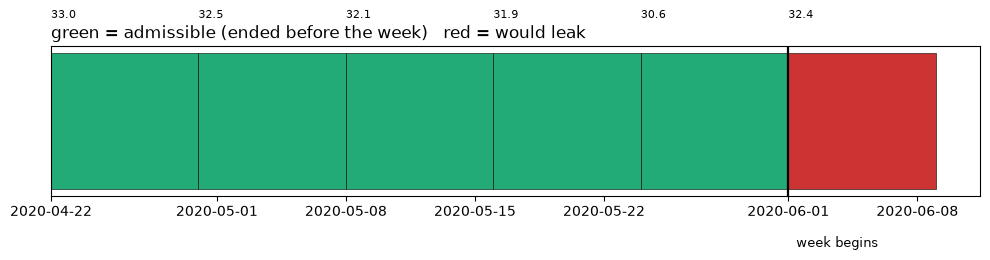

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.2))
for _, r in win.iterrows():
    ok = r.composite_end < EX_WEEK
    ax.barh(0, (r.composite_end - r.composite_start).days + 1, left=r.composite_start,
            height=.5, color="#2a7" if ok else "#c33", edgecolor="k", lw=.4)
    ax.text(r.composite_start, .38, f"{r.lst_day_mean:.1f}", fontsize=8)
ax.axvline(EX_WEEK, color="k", lw=1.6)
ax.text(EX_WEEK, -.45, "  week begins", fontsize=9, va="center")
ax.set_yticks([])
ax.set_title("green = admissible (ended before the week)   red = would leak", loc="left")
plt.tight_layout()

Now the rule as code. `merge_asof(..., direction="backward", allow_exact_matches=False)` on
`composite_end` picks the most recent composite ending **strictly before** the cut date — which is
exactly the sentence above, and also does the past-only gap fill for free: dropping nulls before
the merge means the search walks further back rather than interpolating.

The cut date for lag *k* is `week_start - 7k days`, so one function covers every lag and both
cadences without special-casing either.

In [10]:
def asof_lag(spine, src, col, k):
    """Most recent non-null `col` from a composite ending strictly before (week_start - 7k days).

    Returns the value plus the age in days of the observation it came from.
    """
    left = spine[["rdhs_id", "week_start"]].copy()
    left["cut"] = left["week_start"] - pd.Timedelta(days=7 * k)
    left = left.sort_values("cut")

    right = (src[["rdhs_id", "composite_end", col]]
             .dropna(subset=[col])                     # past-only fill: skip cloud, never interpolate
             .sort_values("composite_end"))

    out = pd.merge_asof(left, right,
                        left_on="cut", right_on="composite_end", by="rdhs_id",
                        direction="backward", allow_exact_matches=False)
    out["age_days"] = (out["cut"] - out["composite_end"]).dt.days
    return out          # keyed by (rdhs_id, week_start) — join on the keys, never on position


demo = asof_lag(spine, lst, "lst_day_mean", 0)
row = demo[(demo.rdhs_id == EX_UNIT) & (demo.week_start == EX_WEEK)].iloc[0]
print(f"lag 0 for {EX_UNIT} @ {EX_WEEK.date()}:")
print(f"  cut date        {row.cut.date()}")
print(f"  composite ends  {row.composite_end.date()}   ({row.age_days} days before the week)")
print(f"  value           {row.lst_day_mean:.2f} degC")
print("\nmatches the green bar nearest the line, by hand and by code.")

lag 0 for RDHS_01 @ 2020-06-01:
  cut date        2020-06-01
  composite ends  2020-05-31   (1 days before the week)
  value           30.57 degC

matches the green bar nearest the line, by hand and by code.


In [11]:
print("first three lags, same district and week:\n")
for k in LAGS[:3]:
    r = asof_lag(spine, lst, "lst_day_mean", k)
    r = r[(r.rdhs_id == EX_UNIT) & (r.week_start == EX_WEEK)].iloc[0]
    print(f"  lag {k}: cut {r.cut.date()} -> composite ending {r.composite_end.date()}"
          f"  value {r.lst_day_mean:6.2f}  age {r.age_days:>2}d")

first three lags, same district and week:

  lag 0: cut 2020-06-01 -> composite ending 2020-05-31  value  30.57  age  1d
  lag 1: cut 2020-05-25 -> composite ending 2020-05-23  value  31.95  age  2d
  lag 2: cut 2020-05-18 -> composite ending 2020-05-15  value  32.08  age  3d


## 6 · What the naive join would have cost

The obvious implementation — match each week to the composite whose *start* date it falls in — is
one keyword different and looks just as correct in a diff. Measure the difference rather than
argue about it.

In [12]:
naive = pd.merge_asof(
    spine[["rdhs_id", "week_start"]].sort_values("week_start"),
    lst[["rdhs_id", "composite_start", "composite_end", "lst_day_mean"]]
       .dropna(subset=["lst_day_mean"]).sort_values("composite_start"),
    left_on="week_start", right_on="composite_start", by="rdhs_id",
    direction="backward", allow_exact_matches=True)

leaked = naive.composite_end >= naive.week_start
print(f"naive join   : {leaked.mean():6.1%} of rows use a composite that extends into the week")
print(f"              ({leaked.sum():,} of {len(naive):,} district-weeks)")
print(f"              median days of future observation inside the predictor: "
      f"{(naive.composite_end[leaked] - naive.week_start[leaked]).dt.days.median():.0f}")

safe = asof_lag(spine, lst, "lst_day_mean", 0)
print(f"as-of join   : {(safe.composite_end >= safe.week_start).mean():6.1%} — by construction")

naive join   :  91.4% of rows use a composite that extends into the week
              (9,936 of 10,868 district-weeks)
              median days of future observation inside the predictor: 3
as-of join   :   0.0% — by construction


Both versions produce a full column of plausible temperatures, and no downstream metric would look
wrong. A model fit on the naive column is reading the week it is predicting.

## 7 · Source coverage — audit before joining

Forward-fill is only cheap when gaps are short. Plot when composites actually exist, per product,
before the fill hides the answer.

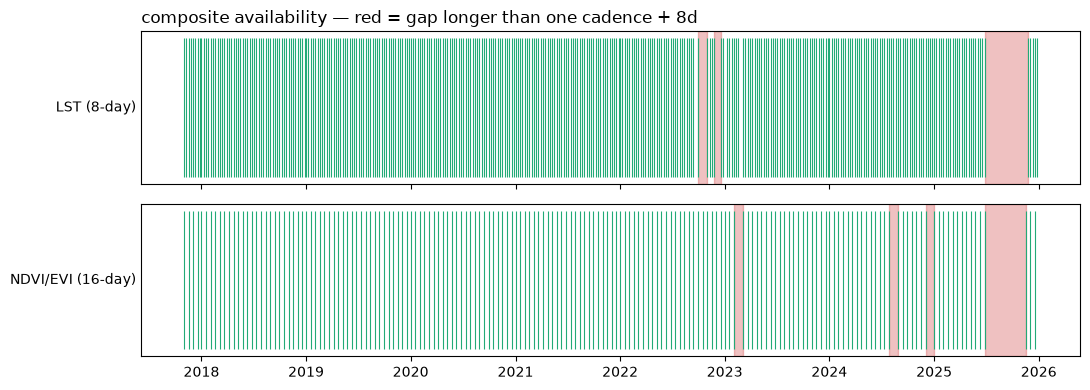

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True)
for ax, (nm, d, cad) in zip(axes, [("LST (8-day)", lst, 8), ("NDVI/EVI (16-day)", vi, 16)]):
    comps = d[["composite_start", "composite_end"]].drop_duplicates().sort_values("composite_start")
    ax.vlines(comps.composite_start, 0, 1, lw=.8, color="#2a7")
    gaps = comps.composite_start.diff().dt.days
    for _, g in comps[gaps > cad + 8].assign(gap=gaps).iterrows():
        ax.axvspan(g.composite_start - pd.Timedelta(days=g.gap), g.composite_start,
                   color="#c33", alpha=.30)
    ax.set_yticks([]); ax.set_ylabel(nm, rotation=0, ha="right", va="center")
axes[0].set_title("composite availability — red = gap longer than one cadence + 8d", loc="left")
plt.tight_layout()

In [14]:
print("gaps longer than one cadence:\n")
for nm, d, cad in [("LST", lst, 8), ("VI", vi, 16)]:
    comps = d[["composite_start", "composite_end"]].drop_duplicates().sort_values("composite_start")
    gaps = comps.composite_start.diff().dt.days
    big = comps.assign(gap_days=gaps)[gaps > cad + 2]
    print(f"{nm}:")
    print(big.assign(missing_from=lambda x: x.composite_start - pd.to_timedelta(x.gap_days, "D"))
             [["missing_from", "composite_start", "gap_days"]].to_string(index=False))
    print()

gaps longer than one cadence:

LST:
missing_from composite_start  gap_days
  2022-09-14      2022-09-30      16.0
  2022-09-30      2022-11-01      32.0
  2022-11-25      2022-12-19      24.0
  2022-12-27      2023-01-09      13.0
  2023-02-18      2023-03-06      16.0
  2025-06-26      2025-11-25     152.0

VI:
missing_from composite_start  gap_days
  2023-02-02      2023-03-06      32.0
  2024-07-27      2024-08-28      32.0
  2024-12-02      2025-01-01      30.0
  2025-06-26      2025-11-17     144.0



### The 2025 hole

Both products stop after the composite beginning **2025-06-26** and resume in mid-November — the
same ~4.5 months absent from two independent MODIS products. A shared gap across products is not
cloud; it is the source. Either the catalogue had not ingested that period when notebook 02 ran, or
the search paged out silently.

The consequence is specific: forward-fill would carry a June observation across the whole of the
2025 monsoon and hand the model a *dynamic* feature that is constant for twenty weeks — the exact
failure mode notebook 02 §15 argued M6 must avoid. §9 flags every one of those weeks, and the
design note at the end proposes truncating the panel rather than modelling them.

In [15]:
GAP_FROM, GAP_TO = pd.Timestamp("2025-07-04"), pd.Timestamp("2025-11-17")
affected = WEEKS[(WEEKS >= GAP_FROM) & (WEEKS <= GAP_TO + pd.Timedelta(days=14))]
print(f"spine weeks with no fresh MODIS behind them: {len(affected)} "
      f"({100*len(affected)/len(WEEKS):.1f}% of the spine)")
print(f"  {affected[0].date()} .. {affected[-1].date()}")
print(f"  district-weeks affected: {len(affected) * N_UNITS:,}")

spine weeks with no fresh MODIS behind them: 22 (5.3% of the spine)
  2025-07-07 .. 2025-12-01
  district-weeks affected: 572


## 8 · Run the join

Six dynamic layers × nine lags. Each call is the function hand-verified in §5, so nothing new
happens — except one thing that is not visible in the function and cost this notebook a wrong
matrix on the first run.

**`merge_asof` does not preserve the left frame's index.** It requires the left sorted by the join
key, and returns a frame with a fresh `RangeIndex` in *that* order. Writing the result back with
`dyn[col] = j[col].values` therefore assigns cut-date order into district-major order and scrambles
every value across districts and weeks.

Nothing catches it. The column is full, seasonal, correctly ranged, and every leakage check in §12
still passes, because each check re-derives its own frame and is self-consistent within it. So the
result is joined **on the keys**, and the alignment is asserted rather than assumed.

In [16]:
dyn = spine[["rdhs_id", "week_start"]].copy()
ages = {}          # (product, lag) -> age frame, kept for the §9 audit

for prod, cols in DYN_COLS.items():
    src = lst if prod == "lst" else vi
    for k in LAGS:
        for col in cols:
            j = asof_lag(spine, src, col, k)
            dyn = dyn.merge(
                j[["rdhs_id", "week_start", col]].rename(columns={col: f"{col}_lag{k}"}),
                on=["rdhs_id", "week_start"], how="left", validate="1:1")
            if col in ("lst_day_mean", "ndvi_mean"):        # primary column of each product
                ages[(prod, k)] = j[["rdhs_id", "week_start", "age_days"]]

assert len(dyn) == len(spine), "join changed the row count"
assert (dyn.rdhs_id.values == spine.rdhs_id.values).all(), "district order diverged from the spine"
assert (dyn.week_start.values == spine.week_start.values).all(), "week order diverged from the spine"

print("dynamic block:", dyn.shape, "| aligned to the spine row-for-row")
nulls = dyn.filter(like="_lag").isna().sum()
print("\ncolumns with any null:", int((nulls > 0).sum()), "of", len(nulls))
print(nulls[nulls > 0].to_string() if (nulls > 0).any() else "none")

dynamic block: (10868, 56) | aligned to the spine row-for-row

columns with any null: 12 of 54
lst_day_mean_lag7       5
lst_night_mean_lag7    26
lst_mean_lag7           5
lst_dtr_lag7           26
lst_day_mean_lag8      31
lst_night_mean_lag8    52
lst_mean_lag8          31
lst_dtr_lag8           52
ndvi_mean_lag7         26
evi_mean_lag7          26
ndvi_mean_lag8         52
evi_mean_lag8          52


Nulls should exist only where the walk-back runs off the start of the record — notebook 02's
2017-11 pre-roll is 8.5 weeks, so the deepest lags at the very first weeks of 2018 have nothing
behind them. Check that rather than assert it: if a null appears later in the window it means a
district has *no* valid observation before that date, which would be a different problem.

In [17]:
null_rows = dyn[dyn.filter(like="_lag").isna().any(axis=1)]
print("rows with any null   :", len(null_rows))
print("week range           :", null_rows.week_start.min().date(), "->", null_rows.week_start.max().date())
print("districts affected   :", null_rows.rdhs_id.nunique(), "of", N_UNITS)
print("weeks affected       :", null_rows.week_start.nunique())

preroll_end = pd.Timestamp(WIN_START) + pd.Timedelta(weeks=max(LAGS))
print("\npre-roll exhausted by:", preroll_end.date())
assert null_rows.week_start.max() <= preroll_end, \
    "a null falls outside the pre-roll — a district is missing its whole early record, investigate"
print("all nulls fall inside the pre-roll, as expected")

rows with any null   : 52
week range           : 2018-01-01 -> 2018-01-08
districts affected   : 26 of 26
weeks affected       : 2

pre-roll exhausted by: 2018-02-26
all nulls fall inside the pre-roll, as expected


## 9 · Staleness — how much of this is real observation?

Every dynamic cell now has a value. Some are a five-day-old satellite pass; some are a five-month-old
one carried forward. The distinction is invisible in the value column and decisive for the model, so
it gets its own audit and its own flag.

age in days of the observation behind each lag-0 cell:

           LST       VI
count  10868.0  10868.0
mean       8.8     12.0
std       19.4     17.6
min        1.0      1.0
50%        5.0      9.0
90%        8.0     16.0
95%       24.0     24.0
99%      123.0    115.0
max      151.0    143.0


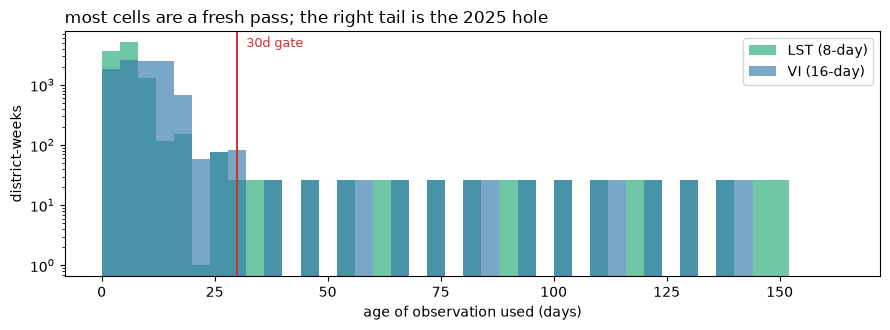

In [18]:
for prod, name in [("lst", "lst_age_days_lag0"), ("vi", "vi_age_days_lag0")]:
    dyn = dyn.merge(ages[(prod, 0)].rename(columns={"age_days": name}),
                    on=["rdhs_id", "week_start"], how="left", validate="1:1")

age_lst, age_vi = dyn["lst_age_days_lag0"], dyn["vi_age_days_lag0"]

print("age in days of the observation behind each lag-0 cell:\n")
print(pd.DataFrame({"LST": age_lst.describe([.5, .9, .95, .99]),
                    "VI":  age_vi.describe([.5, .9, .95, .99])}).round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 3.4))
bins = np.arange(0, 165, 4)
ax.hist(age_lst, bins=bins, alpha=.65, label="LST (8-day)", color="#2a7")
ax.hist(age_vi,  bins=bins, alpha=.65, label="VI (16-day)", color="#37a")
ax.axvline(MAX_AGE_DAYS, color="#c33", lw=1.4)
ax.text(MAX_AGE_DAYS + 2, ax.get_ylim()[1] * .8, f"{MAX_AGE_DAYS}d gate", color="#c33", fontsize=9)
ax.set_yscale("log"); ax.set_xlabel("age of observation used (days)"); ax.set_ylabel("district-weeks")
ax.set_title("most cells are a fresh pass; the right tail is the 2025 hole", loc="left")
ax.legend()
plt.tight_layout()

In [19]:
dyn["stale_flag"] = (dyn[["lst_age_days_lag0", "vi_age_days_lag0"]].max(axis=1) > MAX_AGE_DAYS)

print(f"flagged stale (> {MAX_AGE_DAYS}d): {dyn.stale_flag.mean():.2%} of district-weeks "
      f"({int(dyn.stale_flag.sum()):,} rows)")
print("\nby year:")
print(dyn.groupby(dyn.week_start.dt.year).stale_flag.mean().mul(100).round(1).to_string())

flagged stale (> 30d): 4.78% of district-weeks (520 rows)

by year:
week_start
2018     0.0
2019     0.0
2020     0.0
2021     0.0
2022     1.9
2023     1.9
2024     0.0
2025    34.6


Where the stale rows sit in time — the audit that matters is *when*, not *how many*.

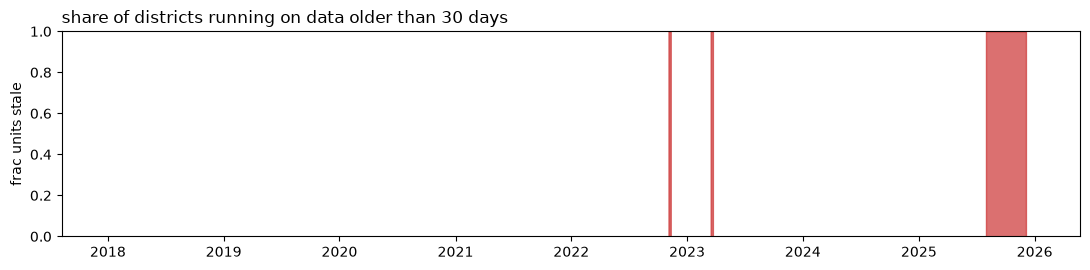

In [20]:
byweek = dyn.groupby("week_start").stale_flag.mean()
fig, ax = plt.subplots(figsize=(11, 2.8))
ax.fill_between(byweek.index, byweek.values, color="#c33", alpha=.7, step="mid")
ax.set_ylabel("frac units stale"); ax.set_ylim(0, 1)
ax.set_title(f"share of districts running on data older than {MAX_AGE_DAYS} days", loc="left")
plt.tight_layout()

## 10 · The static block

Batch A terrain and batch B settlement structure, broadcast to every week of their district.

Two deliberate choices, both already settled and honoured rather than re-litigated here:

- **Single-epoch land cover, not year-by-year.** Notebook 03 §4 measured island built-up moving
  16.7% → 18.5% → 17.3% with **0 of 26 districts monotone**; that is the classifier relabelling the
  same ground, and joining it per-year would feed reclassification noise to the model as if it were
  urbanisation. The per-year tables stay frozen as the evidence and as a sensitivity.
- **`elev_n_px` is dropped.** It is a zonal pixel count — a QC diagnostic from notebook 01, not a
  landscape predictor.

In [21]:
static = (terrain.drop(columns=["rdhs_name", "elev_n_px"])
          .merge(statics.drop(columns=["rdhs_name"]), on="rdhs_id", validate="1:1"))

STATIC_COLS = [c for c in static.columns if c != "rdhs_id"]
print("static predictors:", len(STATIC_COLS))
print("  batch A:", len([c for c in STATIC_COLS if c in terrain.columns]))
print("  batch B:", len([c for c in STATIC_COLS if c in statics.columns]))
assert static.rdhs_id.is_unique and len(static) == N_UNITS
print("\n", static.shape, "one row per district, no nulls:", not bool(static.isna().any().any()))

static predictors: 38
  batch A: 20
  batch B: 18

 (26, 39) one row per district, no nulls: True


## 11 · Assemble

Keys first, then static, then dynamic. `geometry_id` (`LK11`…) travels alongside `rdhs_id` because
the frozen panel and the manuscript artifacts key on it — notebook 05 cannot make the panel join
without it.

In [22]:
M = (spine
     .merge(units, on="rdhs_id", validate="many_to_one")
     .merge(static, on="rdhs_id", validate="many_to_one")
     .merge(dyn, on=["rdhs_id", "week_start"], validate="1:1"))

iso = M.week_start.dt.isocalendar()
M.insert(3, "iso_year", iso.year.astype(int).values)
M.insert(4, "iso_week", iso.week.astype(int).values)

KEY_COLS = ["rdhs_id", "geometry_id", "rdhs_name", "week_start", "iso_year", "iso_week"]
QC_COLS  = ["lst_age_days_lag0", "vi_age_days_lag0", "stale_flag"]
DYN_LAG_COLS = [f"{c}_lag{k}" for cols in DYN_COLS.values() for c in cols for k in LAGS]

M = M[KEY_COLS + STATIC_COLS + DYN_LAG_COLS + QC_COLS]
assert not M.columns.duplicated().any(), "duplicate columns in the matrix"

print("model matrix:", M.shape)
print("  rows    :", f"{len(M):,}", "=", N_UNITS, "districts x", len(WEEKS), "weeks")
print("  keys    :", len(KEY_COLS))
print("  static  :", len(STATIC_COLS))
print("  dynamic :", len(DYN_LAG_COLS))
print("  QC      :", len(QC_COLS))
print("  total   :", len(KEY_COLS) + len(STATIC_COLS) + len(DYN_LAG_COLS) + len(QC_COLS))
print("  memory  :", f"{M.memory_usage(deep=True).sum()/1e6:.1f} MB")

model matrix: (10868, 101)
  rows    : 10,868 = 26 districts x 418 weeks
  keys    : 6
  static  : 38
  dynamic : 54
  QC      : 3
  total   : 101
  memory  : 10.3 MB


In [23]:
print(M.dtypes.value_counts().to_string())
print()
M[["rdhs_id", "geometry_id", "week_start", "elev_mean", "frac_built",
   "lst_day_mean_lag0", "lst_day_mean_lag8", "ndvi_mean_lag0", "stale_flag"]].head(4)

float64           92
int64              4
str                3
datetime64[us]     1
bool               1



,rdhs_id,geometry_id,week_start,elev_mean,frac_built,lst_day_mean_lag0,lst_day_mean_lag8,ndvi_mean_lag0,stale_flag
0,RDHS_01,LK11,2018-01-01,34.965519,0.630886,31.066901,NaN,0.685579,False
1,RDHS_01,LK11,2018-01-08,34.965519,0.630886,31.066901,29.658848,0.682760,False
2,RDHS_01,LK11,2018-01-15,34.965519,0.630886,31.140263,31.419192,0.682760,False
3,RDHS_01,LK11,2018-01-22,34.965519,0.630886,30.817068,31.817154,0.652516,False


## 12 · Re-test the leakage rule, mechanically, over every cell

§5 verified one district and one week by eye. This checks all of them: for every lag, the composite
that supplied the value must have ended strictly before that lag's cut date. It re-derives the
provenance of each cell instead of trusting the join that produced it.

In [24]:
violations = 0
checked = 0
for prod, cols in DYN_COLS.items():
    src = lst if prod == "lst" else vi
    for k in LAGS:
        j = asof_lag(spine, src, cols[0], k)
        v = (j.composite_end >= j.cut).sum()          # must be zero: strictly before the cut
        w = (j.composite_end >= j.week_start).sum()   # and therefore before the week itself
        violations += int(v) + int(w)
        checked += len(j)

print(f"checked {checked:,} (district, week, lag) cells across both products")
print(f"cells whose source composite reached the cut date or beyond: {violations}")
assert violations == 0, "LEAKAGE — a predictor contains observations from its own prediction week"
print("\nno predictor cell contains an observation from on or after the week it predicts")

checked 195,624 (district, week, lag) cells across both products
cells whose source composite reached the cut date or beyond: 0

no predictor cell contains an observation from on or after the week it predicts


Both of those checks re-derive their own frame, so both would pass on a matrix whose values had
been scrambled during assembly (§8). This one closes that hole: re-derive a lag independently and
compare it to what is actually stored in `M`, matched on the keys.

In [25]:
check = asof_lag(spine, lst, "lst_day_mean", 3)[["rdhs_id", "week_start", "lst_day_mean"]]
merged = M[["rdhs_id", "week_start", "lst_day_mean_lag3"]].merge(
    check, on=["rdhs_id", "week_start"], validate="1:1")

same = np.isclose(merged.lst_day_mean_lag3, merged.lst_day_mean, equal_nan=True)
print(f"cells compared      : {len(merged):,}")
print(f"stored == re-derived: {same.sum():,}  ({100*same.mean():.2f}%)")
assert same.all(), "stored values do not match an independent re-derivation — assembly misaligned"
print("\nthe values in the matrix are the values the rule selects, for the right district and week")

cells compared      : 10,868
stored == re-derived: 10,868  (100.00%)

the values in the matrix are the values the rule selects, for the right district and week


Then the weaker property that must also hold: lag *k* must be at least as old as lag *k−1*. A
monotonicity break would mean the cut dates are not ordered — a different bug the equality check
above would not catch.

In [26]:
ends = {}
for k in LAGS:
    j = asof_lag(spine, lst, "lst_day_mean", k)
    ends[k] = j.composite_end.values

bad = sum(int((ends[k] > ends[k - 1]).sum()) for k in LAGS[1:])
print("lag-order violations (lag k newer than lag k-1):", bad)
assert bad == 0
print("lags are monotone in time")

lag-order violations (lag k newer than lag k-1): 0
lags are monotone in time


## 13 · QC

Three questions. Is anything missing; is the static block as collinear as notebook 01 warned; and —
the one that decides whether M6 is answerable at all — **did the temporal signal survive the join?**

In [27]:
miss = M.isna().sum()
print("columns with nulls:", int((miss > 0).sum()), "of", M.shape[1])
if (miss > 0).any():
    print(miss[miss > 0].to_string())
    print("\nconfined to the pre-roll weeks at the start of the window:")
    print(M[M.isna().any(axis=1)].week_start.agg(["min", "max"]).to_string())

columns with nulls: 12 of 101
lst_day_mean_lag7       5
lst_day_mean_lag8      31
lst_night_mean_lag7    26
lst_night_mean_lag8    52
lst_mean_lag7           5
lst_mean_lag8          31
lst_dtr_lag7           26
lst_dtr_lag8           52
ndvi_mean_lag7         26
ndvi_mean_lag8         52
evi_mean_lag7          26
evi_mean_lag8          52

confined to the pre-roll weeks at the start of the window:
min   2018-01-01
max   2018-01-08


### Collinearity of the static block

Notebook 01 found batch A strongly collinear — 19 of 28 terrain pairs above |r| > 0.8. Batch B
joins it here, so the question is whether the combined block is any better conditioned.

There is a harder constraint underneath that question. A static feature has exactly **26 distinct
values**, one per district, however many weeks the matrix has. So the static block is 38 features
measured on 26 points: its correlation matrix is **singular by construction**, with at most 25
independent directions no matter how uncorrelated the layers happened to be. Weeks add rows, not
information, to this block.

In [28]:
S = M.drop_duplicates("rdhs_id")[STATIC_COLS]
R = S.corr()
iu = np.triu_indices_from(R, k=1)
pairs = pd.Series(R.values[iu],
                  index=[f"{R.index[i]} ~ {R.columns[j]}" for i, j in zip(*iu)])

print(f"static features        : {len(STATIC_COLS)}")
print(f"distinct rows          : {len(S)}  (districts, not district-weeks)")
print(f"pairs                  : {len(pairs):,}")
print(f"|r| > 0.8              : {(pairs.abs() > .8).sum()}  ({100*(pairs.abs() > .8).mean():.1f}%)")
print(f"|r| > 0.9              : {(pairs.abs() > .9).sum()}")

rank = int(np.linalg.matrix_rank(R.values))
ev = np.clip(np.linalg.eigvalsh(R.values)[::-1], 0, None)
print(f"\nrank of R              : {rank} of {len(STATIC_COLS)} features"
      f"  (ceiling is {N_UNITS - 1} = districts - 1)")
print(f"components for 95% var : {int(np.searchsorted(np.cumsum(ev)/ev.sum(), .95) + 1)}")
print("A condition number is not reported: R is singular, so it is not finite.")
print("\nStability selection is required, as docs/M6.md and the plan's 4a both anticipate.")
print("Strongest pairs:")
print(pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(8).round(3).to_string())

static features        : 38
distinct rows          : 26  (districts, not district-weeks)
pairs                  : 703
|r| > 0.8              : 135  (19.2%)
|r| > 0.9              : 80

rank of R              : 25 of 38 features  (ceiling is 25 = districts - 1)
components for 95% var : 7
A condition number is not reported: R is singular, so it is not finite.

Stability selection is required, as docs/M6.md and the plan's 4a both anticipate.
Strongest pairs:
twi_mean ~ twi_p50                    0.998
water_occurrence_mean ~ water_frac    0.994
hand_mean ~ hand_p90                  0.991
elev_mean ~ elev_p50                  0.990
twi_mean ~ twi_p90                    0.987
twi_p50 ~ twi_p90                     0.986
hand_sd ~ hand_p90                    0.985
slope_mean ~ slope_p50                0.983


Note what that rank implies for `M6.md` §9.5's interim gate — *fit M6 on batch A+B and check it
clears M0*. Beyond being unable to express *when* (the static-predictor argument in notebook 02),
A+B carries at most 25 independent dimensions across 26 districts, so a 38-predictor fit on it is
saturated before it starts. Both reasons point the same way: that gate needs a cross-sectional
baseline, not a weekly one.

### Did the temporal signal survive?

Notebook 02 §15 established that only the dynamic layers carry within-district variance. That was
measured on the *composite* series. This matrix is a different object — resampled to weeks, lagged,
and forward-filled through gaps, all of which push variance toward the between-district component.

If the dynamic columns have gone flat here, M6 is a cross-sectional model wearing a time index and
its weekly AUC would be near chance **by construction**, so this is the check that says whether the
model is worth fitting.

In [29]:
def variance_split(df, col):
    d = df.dropna(subset=[col])
    between = d.groupby("rdhs_id")[col].mean().var(ddof=0)
    within = d.groupby("rdhs_id")[col].var(ddof=0).mean()
    return 100 * within / (between + within)

rows = []
for prod, cols in DYN_COLS.items():
    src = lst if prod == "lst" else vi
    for col in cols:
        rows.append((col, "dynamic",
                     round(variance_split(src, col), 1),                 # raw composite series
                     round(variance_split(M, f"{col}_lag0"), 1),
                     round(variance_split(M, f"{col}_lag8"), 1)))
for col in ["elev_mean", "frac_built", "pop_density_km2"]:
    rows.append((col, "static", 0.0, 0.0, 0.0))

vsplit = pd.DataFrame(rows, columns=["feature", "kind", "within_%_source",
                                     "within_%_lag0", "within_%_lag8"])
print(vsplit.to_string(index=False))
print("\nA static layer is 0% within-unit by construction — it can express *which* district, never *when*.")

dv = vsplit[vsplit.kind == "dynamic"]
drift = (dv["within_%_lag0"] - dv["within_%_source"]).abs()
print(f"\nlargest shift from the composite series to the weekly matrix: {drift.max():.1f} pp")
assert drift.max() < 5, "the join changed the variance structure — resampling or alignment is wrong"

        feature    kind  within_%_source  within_%_lag0  within_%_lag8
   lst_day_mean dynamic             73.8           72.3           72.1
 lst_night_mean dynamic             42.8           43.2           43.2
       lst_mean dynamic             63.8           63.5           63.5
        lst_dtr dynamic             93.2           93.0           92.9
      ndvi_mean dynamic             29.0           28.1           28.1
       evi_mean dynamic             39.5           38.3           38.6
      elev_mean  static              0.0            0.0            0.0
     frac_built  static              0.0            0.0            0.0
pop_density_km2  static              0.0            0.0            0.0

A static layer is 0% within-unit by construction — it can express *which* district, never *when*.

largest shift from the composite series to the weekly matrix: 1.5 pp


That first column is the cross-check that matters. It recomputes the split on the **raw composite
series** — the same quantity notebook 02 §15 reported — and the weekly columns reproduce it to
within a couple of points. Resampling to weeks, lagging and forward-filling left the
between/within structure intact, so the matrix is carrying the same signal notebook 02 measured
rather than an artifact of the join.

It is also the check that caught the alignment bug in §8. Scrambling a column across districts
destroys between-district variance, which inflates the within-unit share: NDVI read **93%** on the
broken matrix against 29% at source. A number that moves the *right way for the argument* is the
easiest kind to accept without checking.

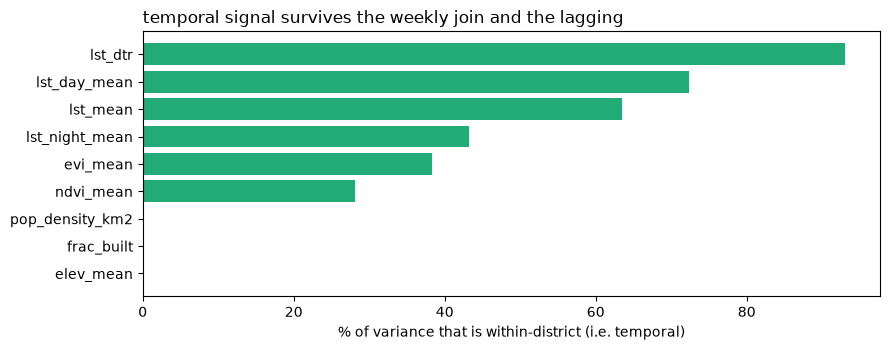

In [30]:
fig, ax = plt.subplots(figsize=(9, 3.6))
s = vsplit.sort_values("within_%_lag0")
ax.barh(s.feature, s["within_%_lag0"],
        color=["#bbb" if k == "static" else "#2a7" for k in s.kind])
ax.set_xlabel("% of variance that is within-district (i.e. temporal)")
ax.set_title("temporal signal survives the weekly join and the lagging", loc="left")
plt.tight_layout()

A district's LST through the join — the fold back to the real world. Flat stretches are the fill.

shaded = stale_flag (forward-filled beyond the gate); note the 2025 block


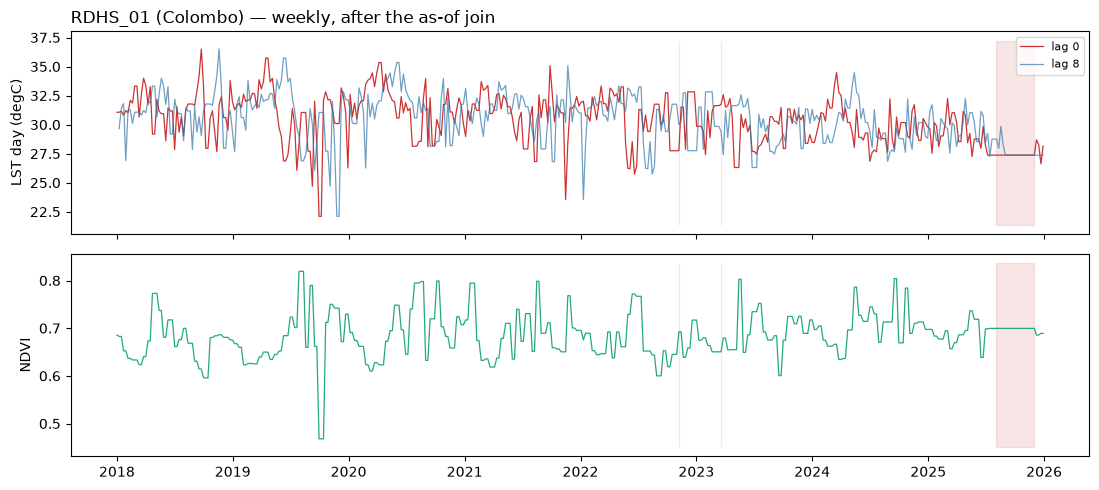

In [31]:
ex = M[M.rdhs_id == EX_UNIT].set_index("week_start")
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(ex.index, ex.lst_day_mean_lag0, lw=.9, color="#c33", label="lag 0")
axes[0].plot(ex.index, ex.lst_day_mean_lag8, lw=.9, color="#37a", alpha=.7, label="lag 8")
axes[0].set_ylabel("LST day (degC)"); axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title(f"{EX_UNIT} ({units.set_index('rdhs_id').loc[EX_UNIT, 'rdhs_name']}) — weekly, after the as-of join", loc="left")
axes[1].plot(ex.index, ex.ndvi_mean_lag0, lw=.9, color="#2a7")
axes[1].set_ylabel("NDVI")
for a in axes:
    a.fill_between(ex.index, *a.get_ylim(), where=ex.stale_flag.values, color="#c33", alpha=.12)
plt.tight_layout()
print("shaded = stale_flag (forward-filled beyond the gate); note the 2025 block")

## 14 · Freeze

Quarantined, gitignored, never committed — same rule as batches A–C.

The filename says `features_weekly`, **not** `model_matrix`. `M6.md` §8 reserves
`m6_model_matrix_srilanka_v1.csv` for the table joined onto the M1/M2/M5 panel spine with its
labels and split flags. This is the feature side on a candidate spine; calling it the model matrix
would imply a comparability guarantee that has not been earned yet.

In [32]:
M.to_csv(OUT_CSV, index=False)

prov = {
    "notebook": "04_feature_assembly",
    "country": "sri_lanka",
    "seed": SEED,
    "window": [WIN_START, WIN_END],
    "spine": {
        "keys": ["rdhs_id", "week_start"],
        "week_convention": "Monday-start; verified against ALT_STATS/frozen/srilanka_matched_pairs.csv",
        "n_units": int(N_UNITS),
        "n_weeks": int(len(WEEKS)),
        "n_rows": int(len(M)),
        "status": "CANDIDATE — not the M1/M2/M5 panel spine (M6.md §8); notebook 05 intersects",
    },
    "leakage_rule": (
        "a composite is admissible for week W only if composite_end < W; lag k uses the last "
        "admissible composite ending before (W - 7k days). allow_exact_matches=False. Verified "
        "mechanically over all (district, week, lag) cells."
    ),
    "gap_fill": "past-only (nulls dropped before merge_asof); interpolation forbidden — reaches forward",
    "alignment": (
        "dynamic columns joined on (rdhs_id, week_start), never positionally: merge_asof returns a "
        "cut-sorted RangeIndex, so a .values assignment scrambles districts and weeks silently. "
        "Asserted against the spine, and each stored column re-derived and compared."
    ),
    "naive_join_leak_frac": round(float(leaked.mean()), 4),
    "lags_weeks": LAGS,
    "features": {
        "static": len(STATIC_COLS),
        "dynamic_layers": sum(len(v) for v in DYN_COLS.values()),
        "dynamic_columns": len(DYN_LAG_COLS),
        "static_block_rank": rank,
        "dropped": ["elev_n_px (zonal pixel count, QC diagnostic not a predictor)"],
        "land_cover_join": "single epoch, not year-by-year (notebook 03 §4 / decision log 2026-08-05)",
    },
    "staleness": {
        "gate_days": MAX_AGE_DAYS,
        "flagged_frac": round(float(dyn.stale_flag.mean()), 4),
        "lst_age_p50": float(age_lst.median()), "lst_age_max": int(age_lst.max()),
        "vi_age_p50": float(age_vi.median()),   "vi_age_max": int(age_vi.max()),
    },
    "source_gap_2025": {
        "absent_from": str(GAP_FROM.date()), "absent_to": str(GAP_TO.date()),
        "affects_both_products": True,
        "note": "shared across LST and VI, so source-side not cloud; see design notes",
    },
    "inputs": {
        "batchA_sha256_16": prov1["output_sha256_16"],
        "batchB_sha256_16": prov3["output_sha256_16"],
        "lst_sha256_16": prov2["lst"]["sha256_16"],
        "vi_sha256_16": prov2["vi"]["sha256_16"],
    },
    "geometry_sha256_16": sha_now,
    "output_sha256_16": hashlib.sha256(OUT_CSV.read_bytes()).hexdigest()[:16],
}
(QUAR / "nb04_provenance.json").write_text(json.dumps(prov, indent=2))
print(json.dumps(prov, indent=2))

{
  "notebook": "04_feature_assembly",
  "country": "sri_lanka",
  "seed": 20260612,
  "window": [
    "2018-01-01",
    "2025-12-31"
  ],
  "spine": {
    "keys": [
      "rdhs_id",
      "week_start"
    ],
    "week_convention": "Monday-start; verified against ALT_STATS/frozen/srilanka_matched_pairs.csv",
    "n_units": 26,
    "n_weeks": 418,
    "n_rows": 10868,
    "status": "CANDIDATE \u2014 not the M1/M2/M5 panel spine (M6.md \u00a78); notebook 05 intersects"
  },
  "leakage_rule": "a composite is admissible for week W only if composite_end < W; lag k uses the last admissible composite ending before (W - 7k days). allow_exact_matches=False. Verified mechanically over all (district, week, lag) cells.",
  "gap_fill": "past-only (nulls dropped before merge_asof); interpolation forbidden \u2014 reaches forward",
  "alignment": "dynamic columns joined on (rdhs_id, week_start), never positionally: merge_asof returns a cut-sorted RangeIndex, so a .values assignment scrambles districts

## 15 · Recap

In [33]:
recap = pd.DataFrame([
    ("spine rows",              f"{len(M):,}",                          f"{N_UNITS} districts x {len(WEEKS)} weeks"),
    ("window",                  f"{WIN_START} .. {WIN_END}",            "matches the WER outcome window"),
    ("week key",                "Monday start",                         "verified vs frozen matched pairs"),
    ("static features",         len(STATIC_COLS),                       f"rank {rank}, ceiling {N_UNITS-1}"),
    ("dynamic columns",         len(DYN_LAG_COLS),                      "6 layers x lags 0-8"),
    ("naive join leak",         f"{leaked.mean():.1%}",                 "rows that would see their own week"),
    ("leakage violations",      violations,                             "after the as-of rule"),
    ("median obs age, LST",     f"{age_lst.median():.0f} d",            f"max {age_lst.max():.0f} d"),
    ("median obs age, VI",      f"{age_vi.median():.0f} d",             f"max {age_vi.max():.0f} d"),
    ("stale-flagged rows",      f"{dyn.stale_flag.mean():.2%}",         f"> {MAX_AGE_DAYS} d old"),
    ("static |r| > 0.8 pairs",  int((pairs.abs() > .8).sum()),          f"of {len(pairs):,} pairs"),
    ("within-unit var, LST d0", f"{vsplit.loc[vsplit.feature=='lst_day_mean','within_%_lag0'].iloc[0]:.0f}%",
                                                                        "static layers: 0%"),
    ("within-unit var, NDVI d0",f"{vsplit.loc[vsplit.feature=='ndvi_mean','within_%_lag0'].iloc[0]:.0f}%",
                                                                        "static layers: 0%"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))

                quantity                    value                               note
              spine rows                   10,868           26 districts x 418 weeks
                  window 2018-01-01 .. 2025-12-31     matches the WER outcome window
                week key             Monday start   verified vs frozen matched pairs
         static features                       38                rank 25, ceiling 25
         dynamic columns                       54                6 layers x lags 0-8
         naive join leak                    91.4% rows that would see their own week
      leakage violations                        0               after the as-of rule
     median obs age, LST                      5 d                          max 151 d
      median obs age, VI                      9 d                          max 143 d
      stale-flagged rows                    4.78%                         > 30 d old
  static |r| > 0.8 pairs                      135                

---

### Design notes carried forward

**The row set is still provisional, and that is the binding constraint.** `M6.md` §8 defines M6's
rows as the M1/M2/M5 panel spine with its committed train/val/test flags
(`predictions_h4_75pct_v1.csv`, `hybrid_model_predictions_v1.csv`). Those are not on this machine,
and `scripts/` holds no Sri Lanka ladder — only the Colombia one. Notebook 05 cannot invent a split:
§11's stop rules make a locally-constructed split a stop condition, not a workaround. This spine is
a superset to be intersected, nothing more.

**Recommend truncating the panel at 2025-06-26 rather than modelling the 2025 hole.** Both MODIS
products are absent 2025-07-04 to 2025-11-17, so ~20 weeks × 26 districts would run on features
forward-filled up to five months. Those rows technically satisfy §8's "gap-fill, never drop the
row" — but the rule assumes a gap-fill that means something, and a dynamic layer held constant for
a monsoon does not. Two honest options, for the PI: end the window at the last real composite, or
keep the weeks and report `stale_flag` as a covariate-quality limitation. Silently forward-filling
them is the one option that is not honest. **Worth re-running notebook 02's search first** — if the
catalogue has since ingested mid-2025, the problem disappears.

**The issue-number ↔ ISO-week mapping is unresolved.** The outcome is keyed `(year, week)` where
`week` is the WER issue number; this spine is keyed by Monday date. They coincide for most of the
year and can differ by one at year boundaries, which would misalign the label by a week — a
silent, systematic error precisely at the December–January transition when dengue peaks. Notebook
05 must reconcile them against the outcome table itself, not against an assumption.

**Batch D is still absent** — healthcare access, relative wealth, connectivity, rice-paddy
phenology. All four are static, so they add cross-sectional detail and no temporal signal. Note
that `M6.md` §9.5's interim gate (fit on A+B, check it clears M0) is **structurally unrunnable as
written**: A and B are entirely static, so against a weekly label they cannot express *when*. The
honest version of that gate tests A+B against a cross-sectional baseline.

**Lags are the same 0–8 weeks M2 uses**, deliberately. The comparison M6 exists to make — does
landscape beat climate-only — is only interpretable if both models get the same temporal reach.